# Ames Housing Price Prediction
Tujuan : Mengembangkan model prediksi harga rumah.

## 1. Data Loading
Tujuan : Load data dari csv.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('AmesHousing.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 2. Data Cleaning dan Transformation
Tujuan : Pembersihan dan persiapan data.

### 2.1 Mengidentifikasi Informasi Dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

### 2.2 Missing Values


In [4]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

Keputusan: Pisahkan kolom yang memiliki missing value lebih dari 75% dan kurang dari 75%.

In [5]:
less = missing_values[missing_values < 2000]
over = missing_values[missing_values >= 2000]

Keputusan: Isi data numerik kosong kategori "less" dengan median.

In [6]:
numeric_features = df[less.index].select_dtypes(include=['number']).columns
df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())

Keputusan: Isi data non-numerik dengan modus.

In [7]:
categorical_features = df[less.index].select_dtypes(include=['object', 'string']).columns

for columns in categorical_features:
    df[columns] = df[columns].fillna(df[columns].mode()[0])

Keputusan: Menghapus kolom dengan banyak nilai yang hilang.

In [8]:
df = df.drop(columns=over.index)

Pengecekan:

In [9]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

### 2.3 Outliers

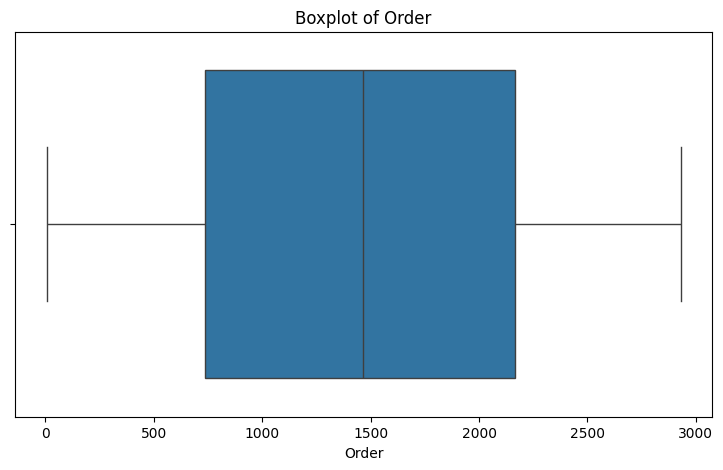

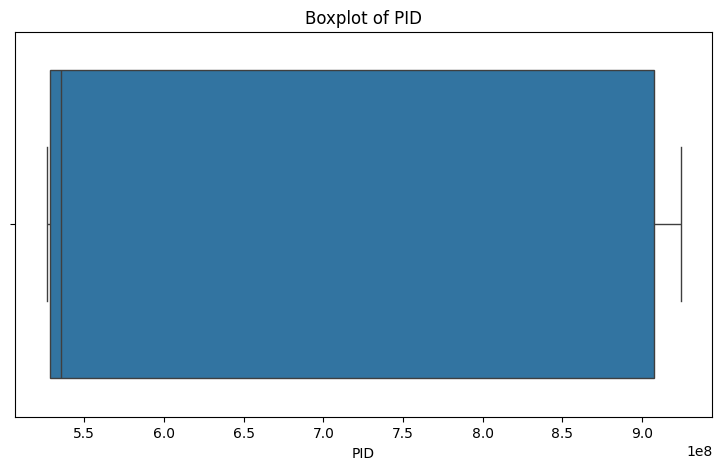

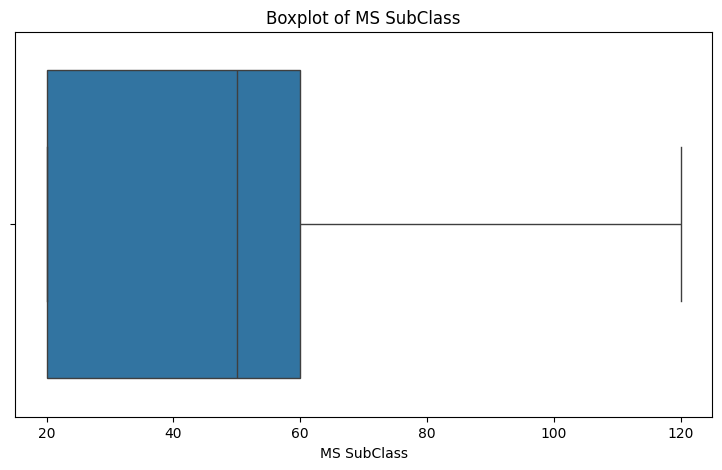

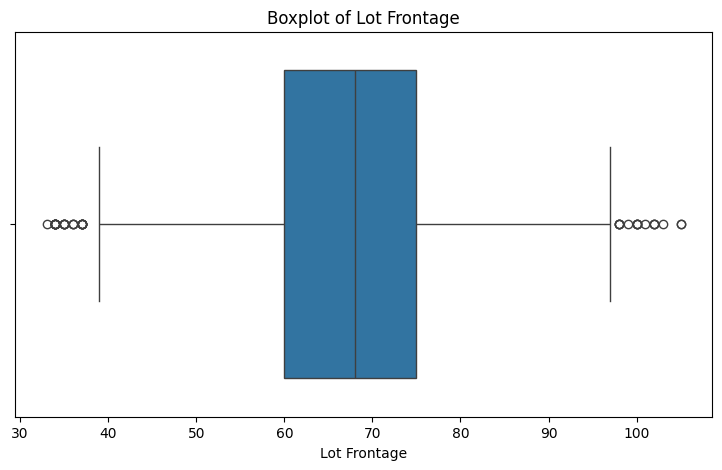

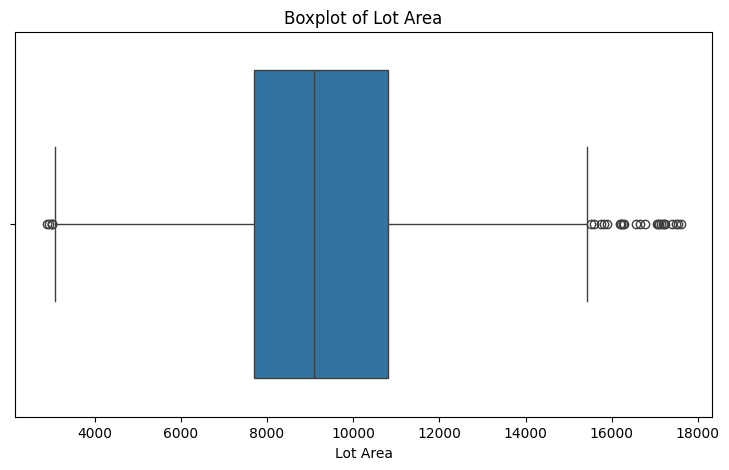

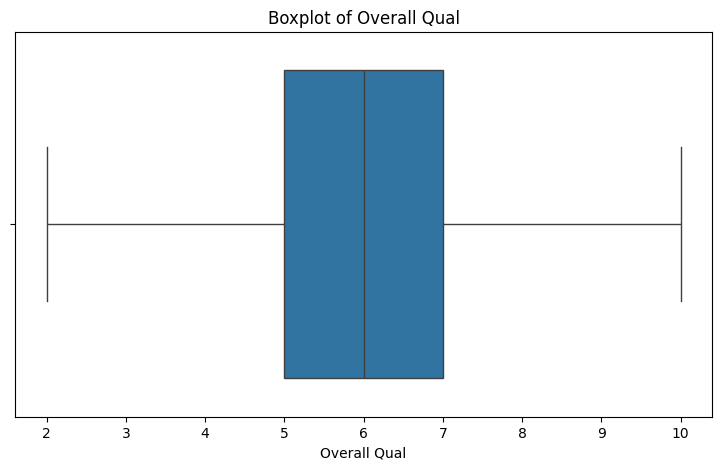

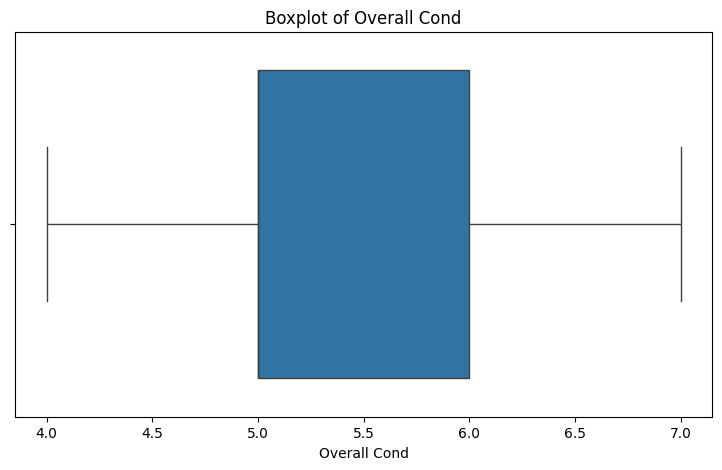

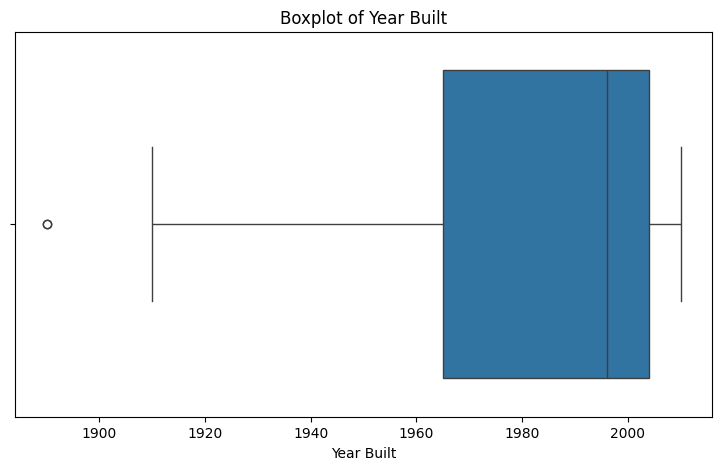

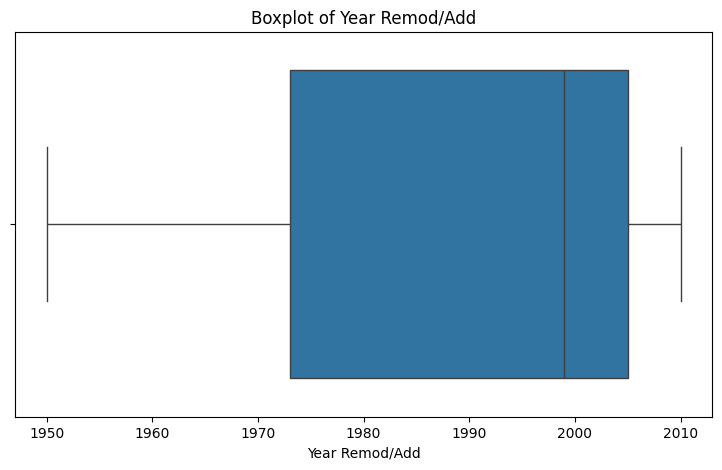

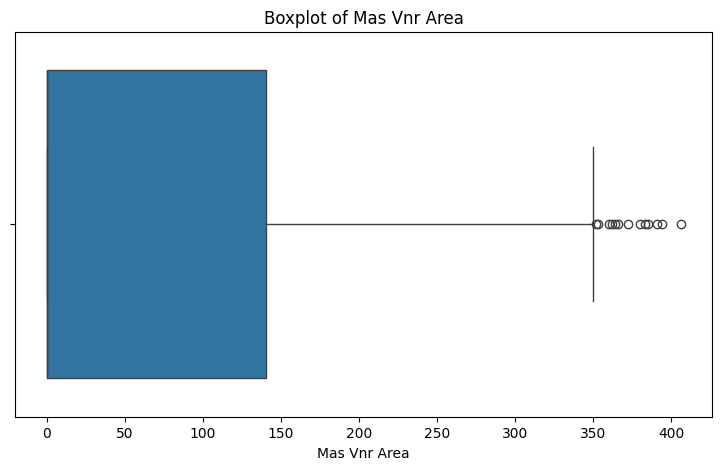

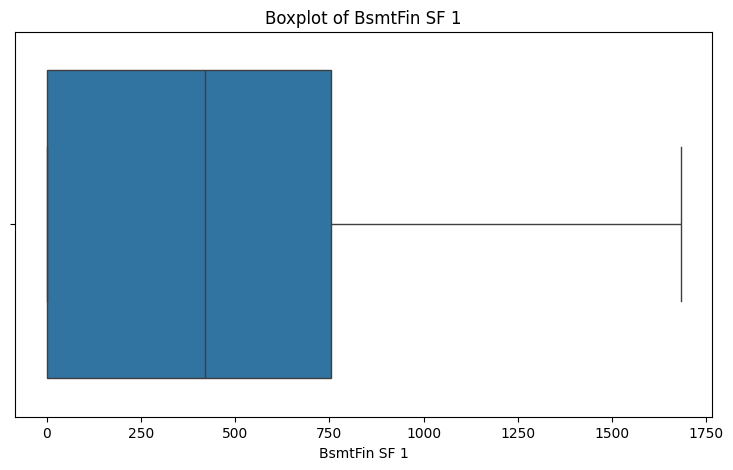

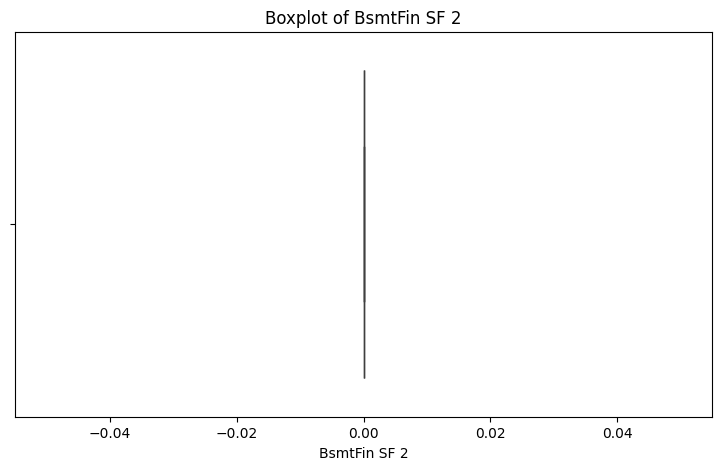

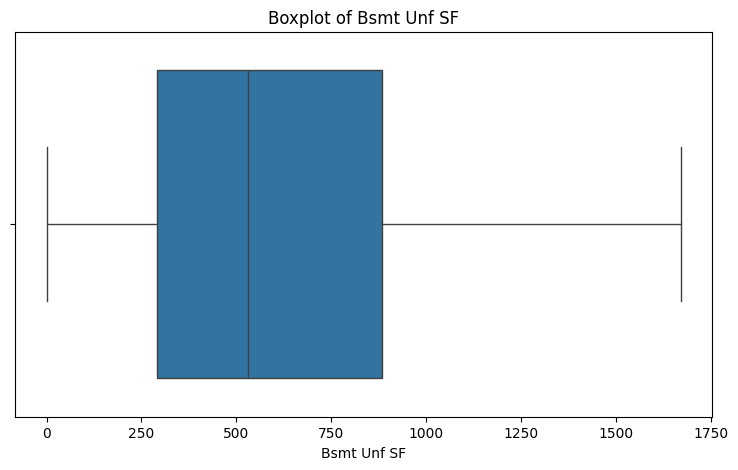

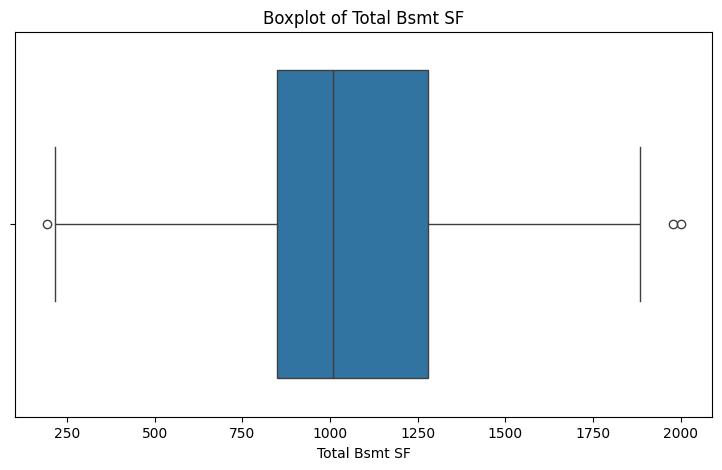

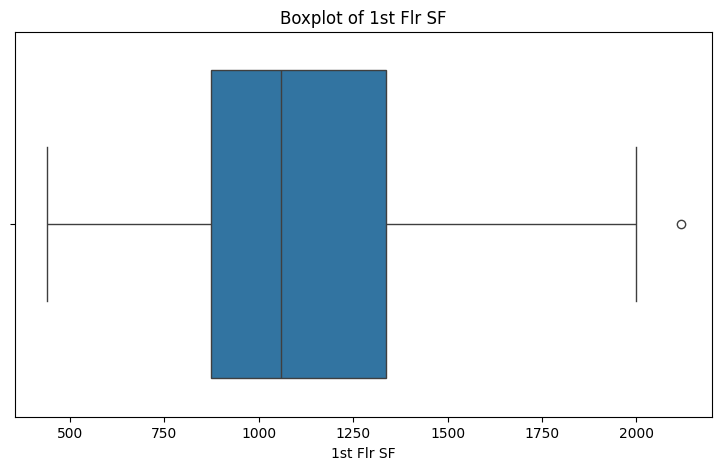

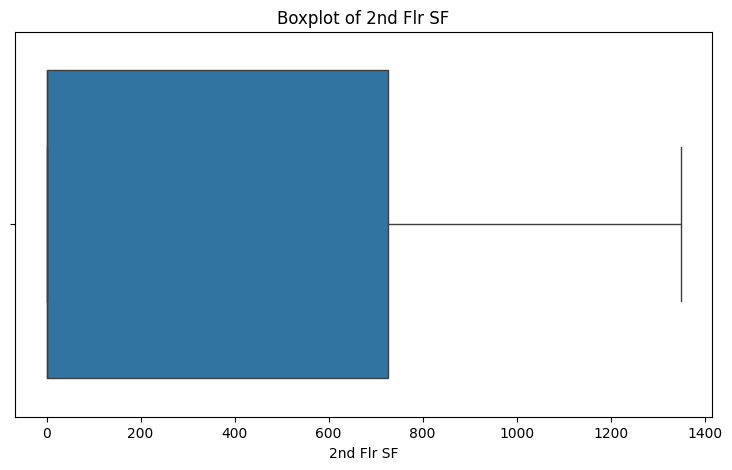

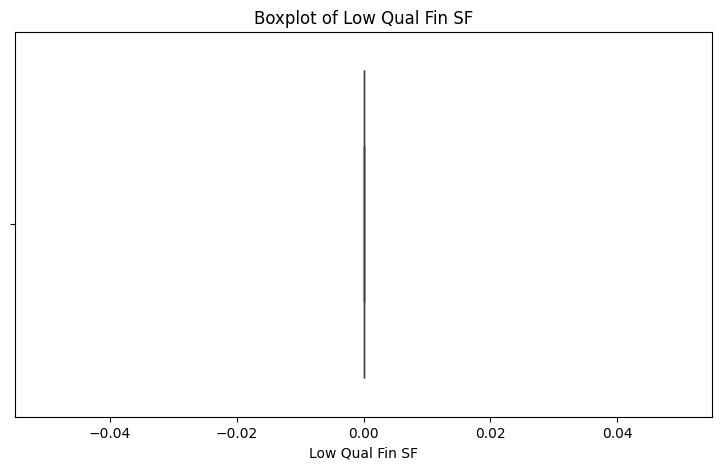

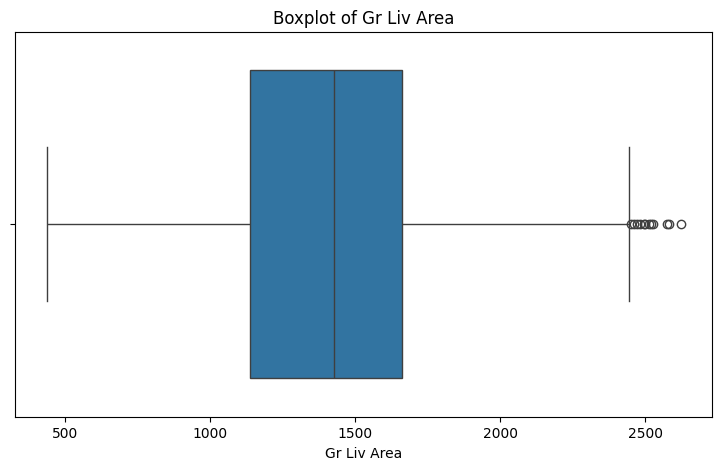

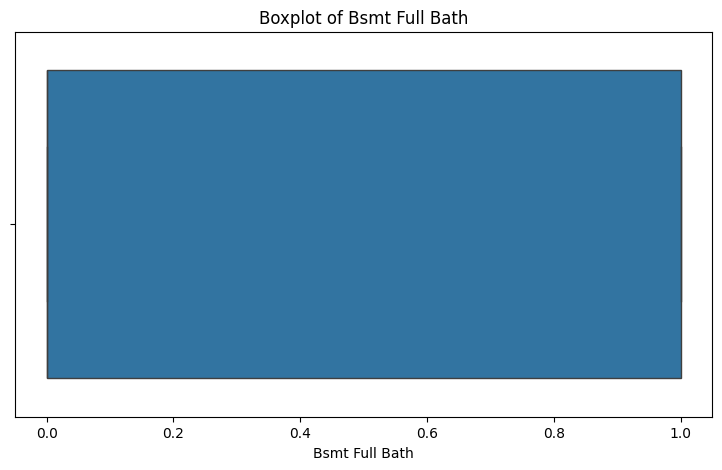

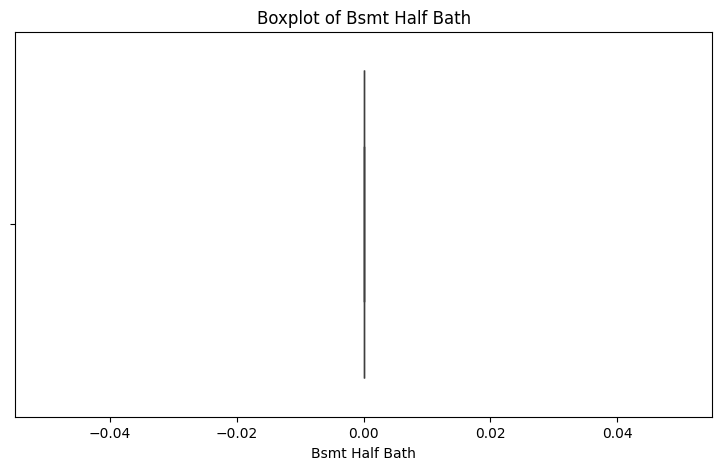

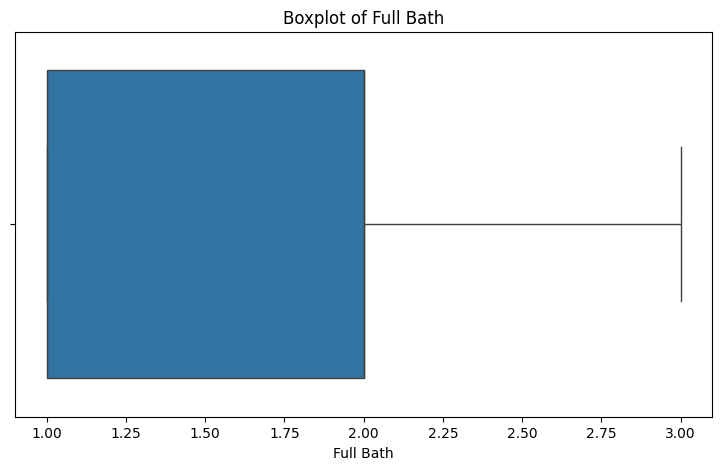

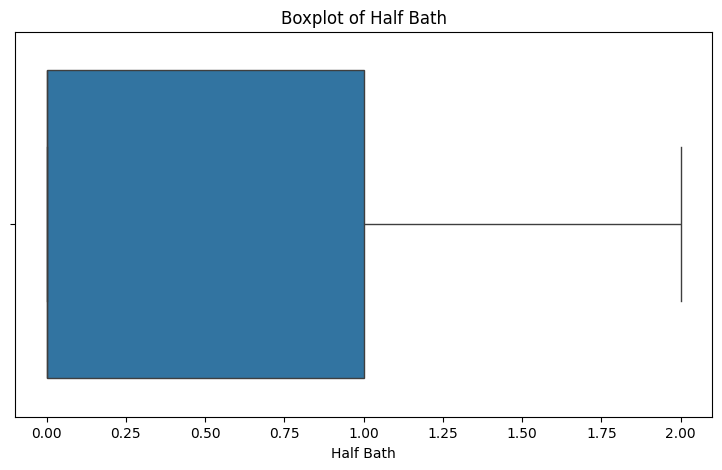

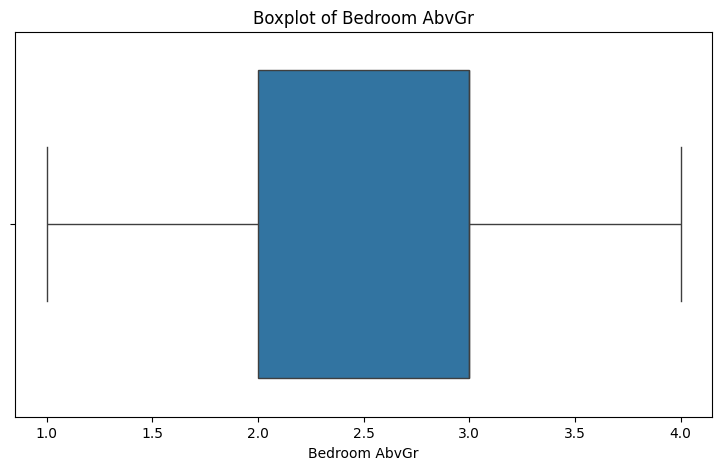

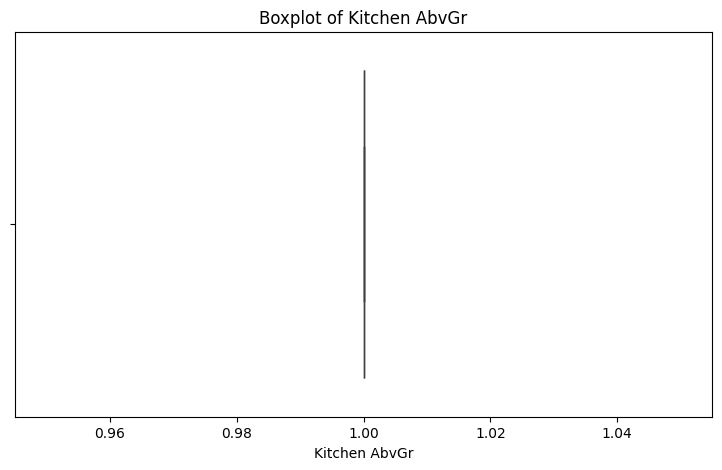

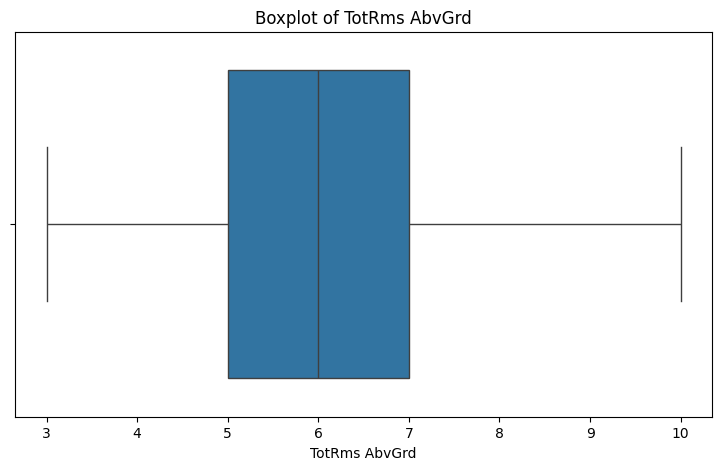

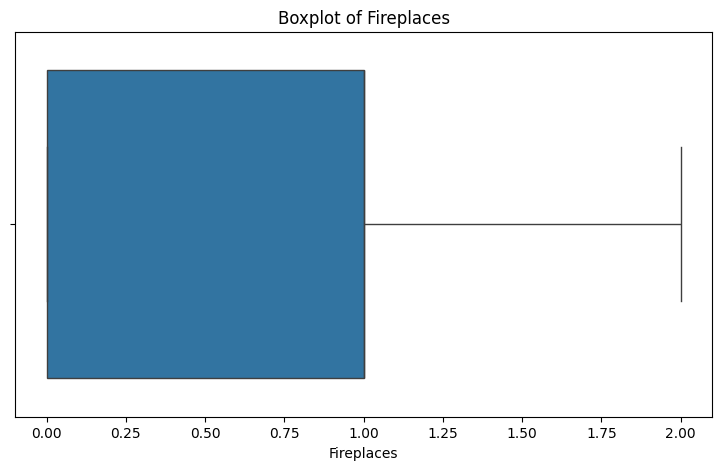

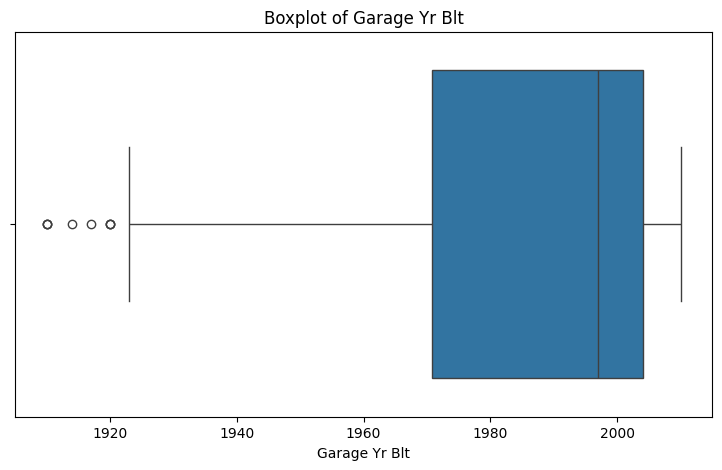

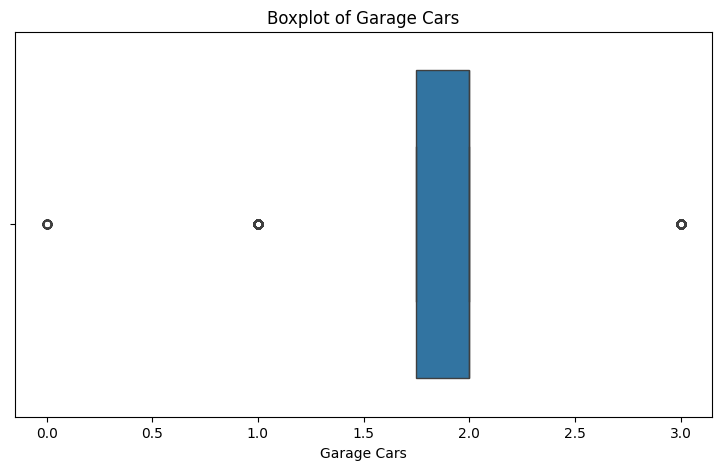

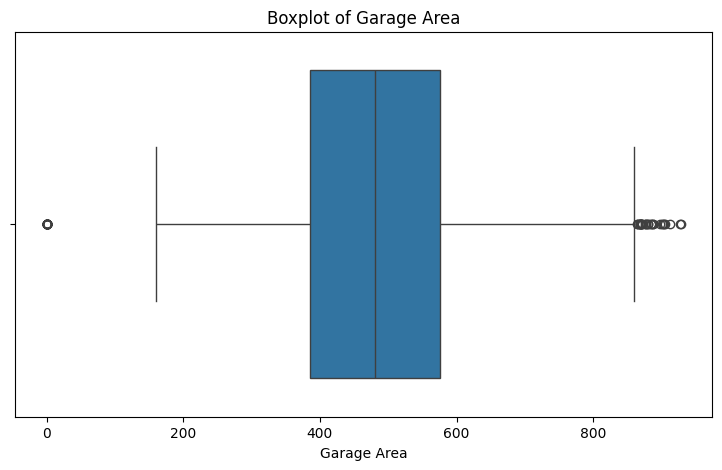

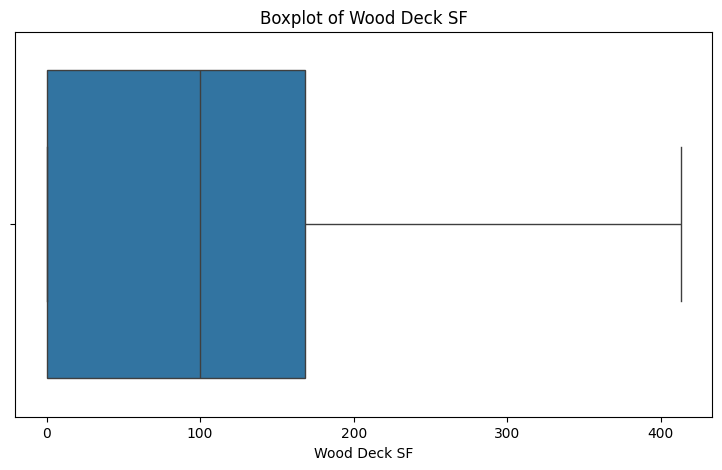

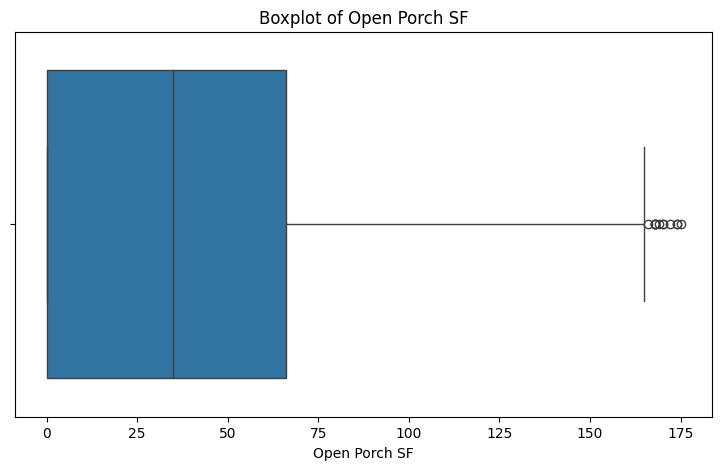

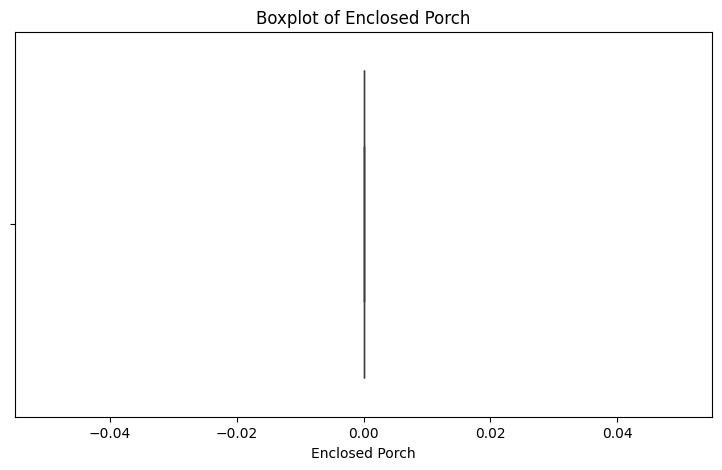

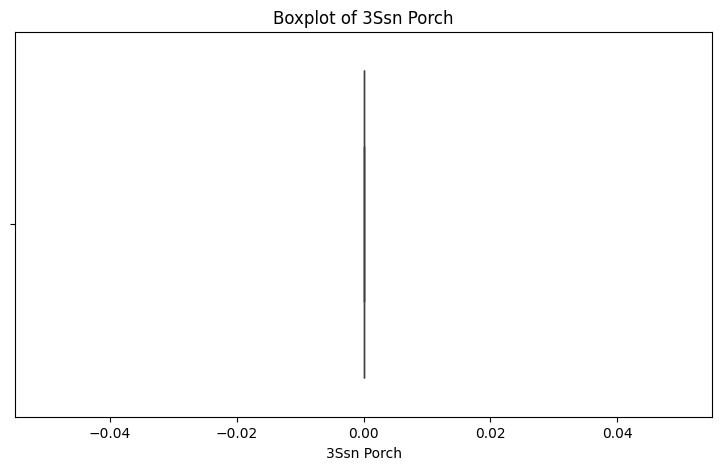

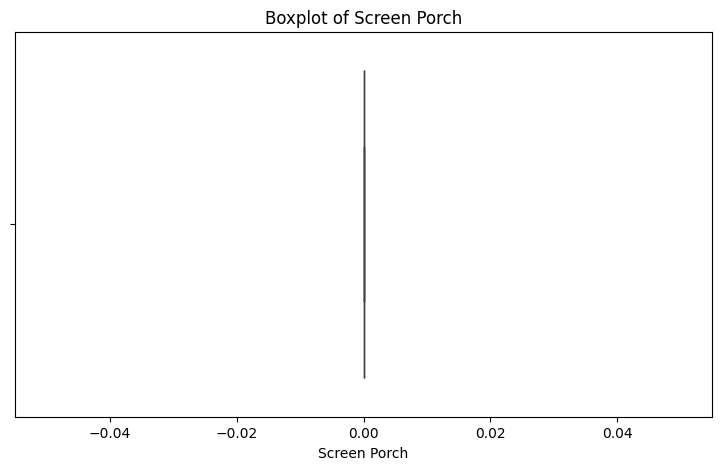

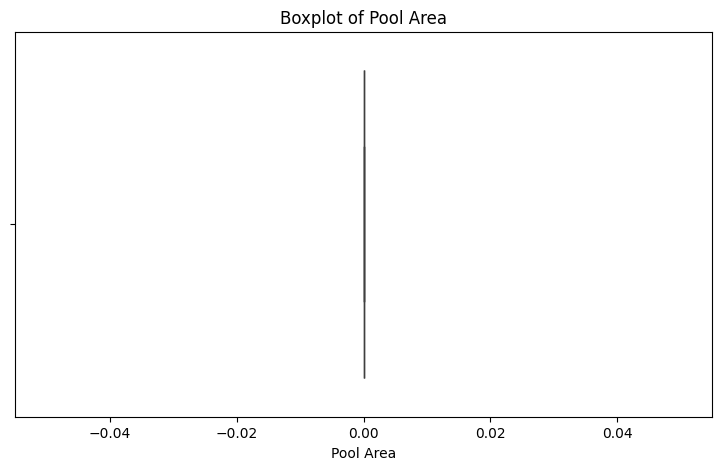

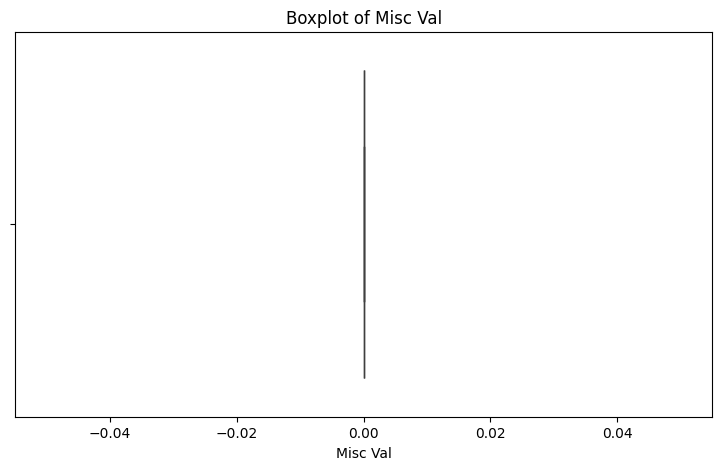

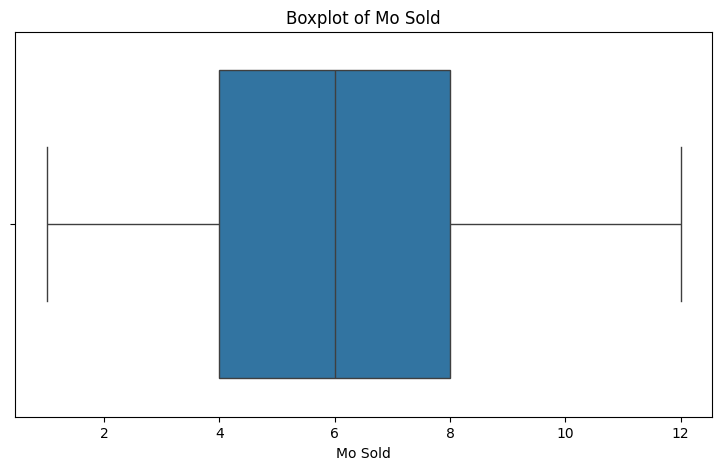

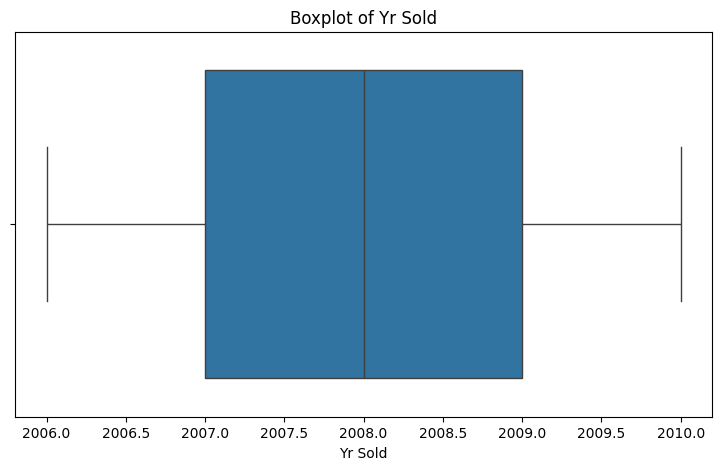

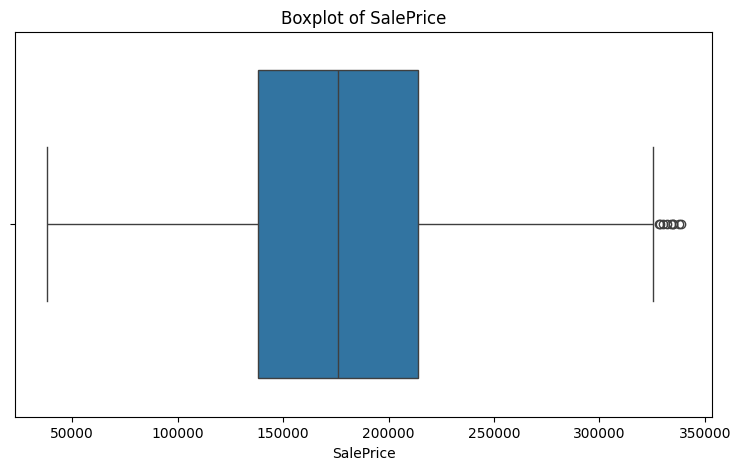

In [14]:
for feature in numeric_features:
    plt.figure(figsize=(9, 5))
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

Keputusan: Menghapus data outlier dengan asumsi bahwa outlier yang terjadi merupakan human error dan tidak ada pengaruh yang besar pada analisis.

Keputusan: Menggunakan metode IQR. 

In [11]:
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1

In [12]:
# Filter dataframe untuk hanya menyimpan baris yang tidak mengandung outliers pada kolom numerik
condition = ~((df[numeric_features] < (Q1 - 1.5 * IQR)) | (df[numeric_features] > (Q3 + 1.5 * IQR))).any(axis=1)
df_filtered_numeric = df.loc[condition, numeric_features]
 
# Menggabungkan kembali dengan kolom kategorikal
categorical_features = df.select_dtypes(include=['object', 'str']).columns
df = pd.concat([df_filtered_numeric, df.loc[condition, categorical_features]], axis=1)

Pengecekan:

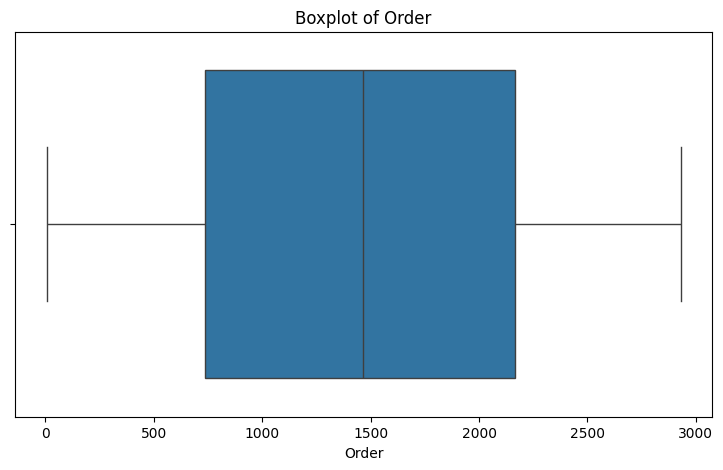

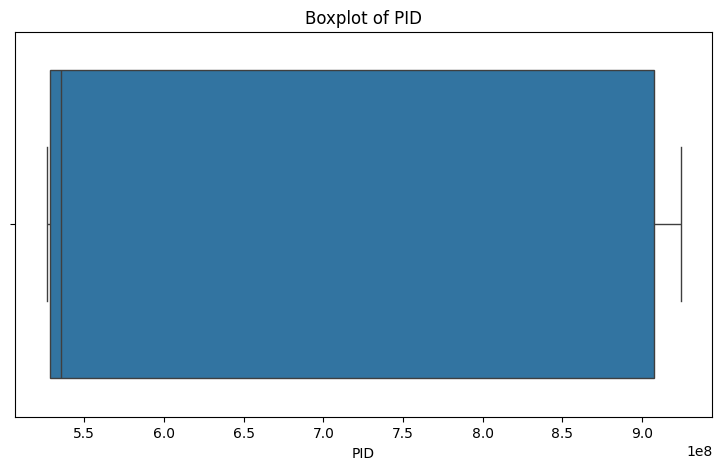

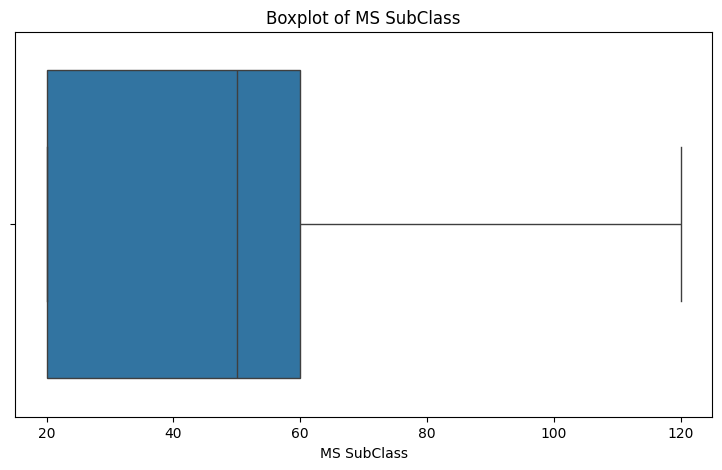

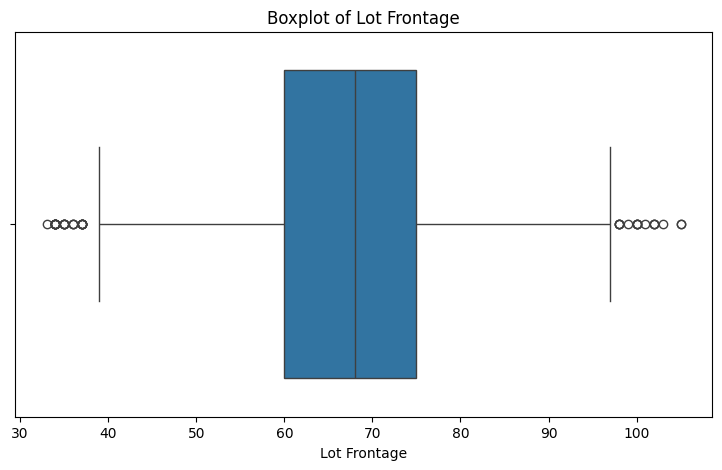

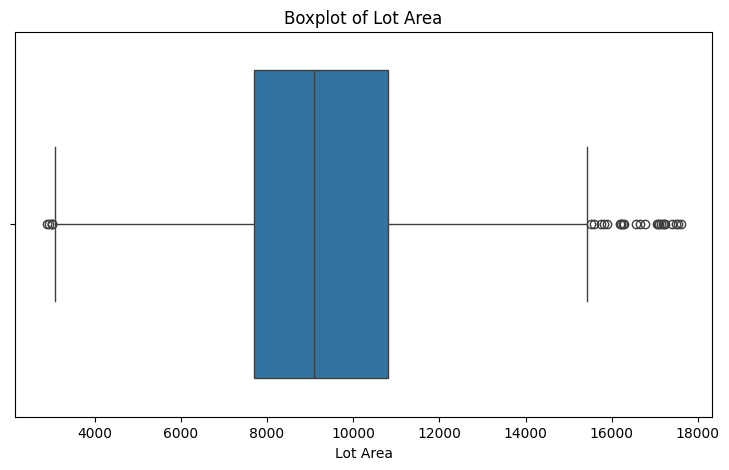

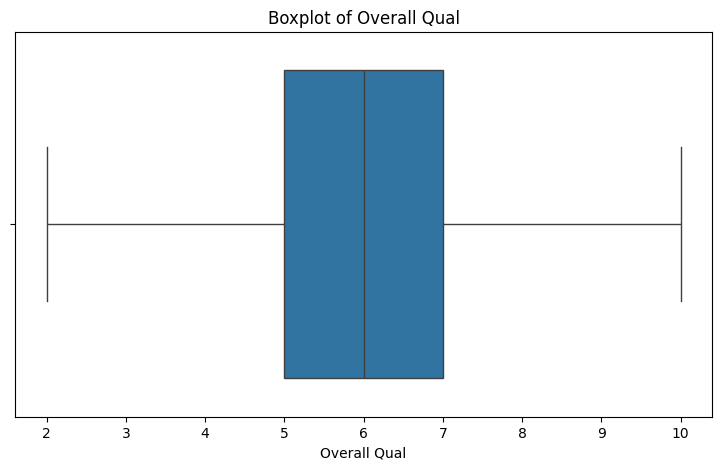

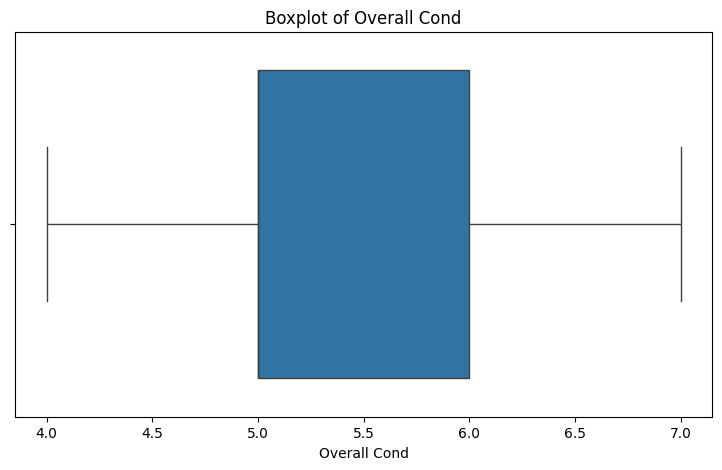

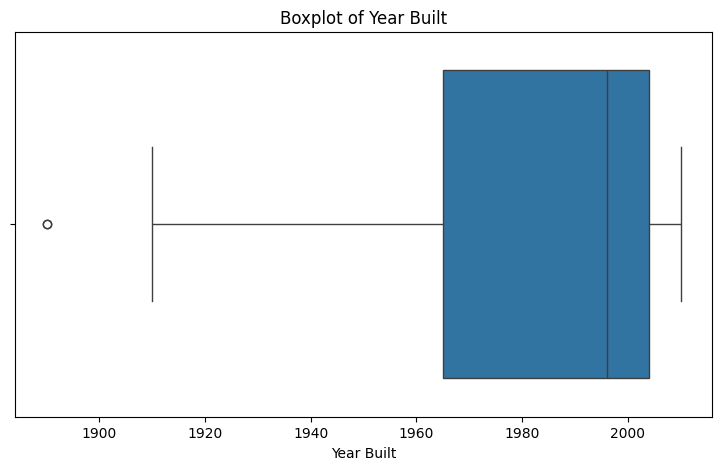

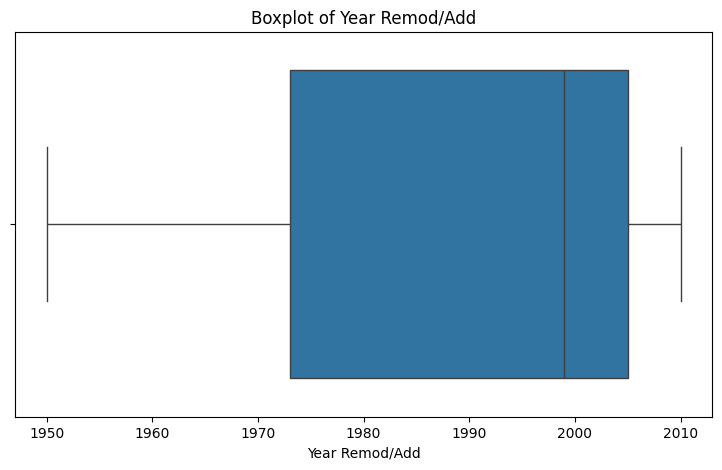

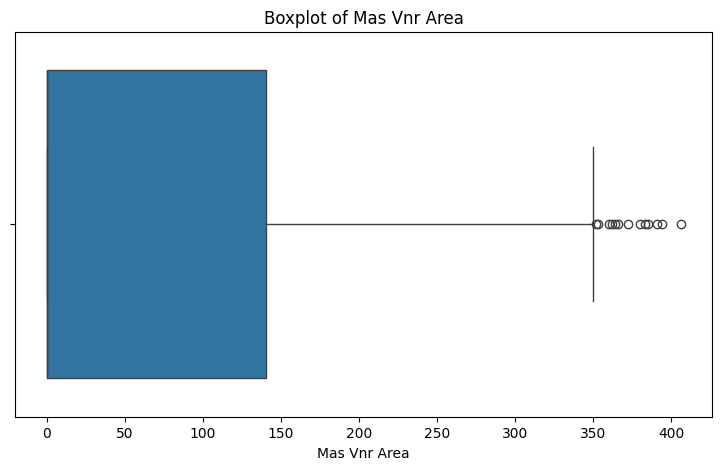

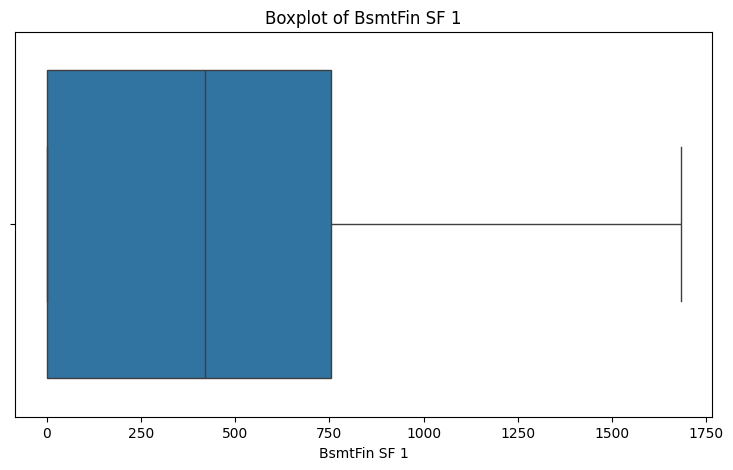

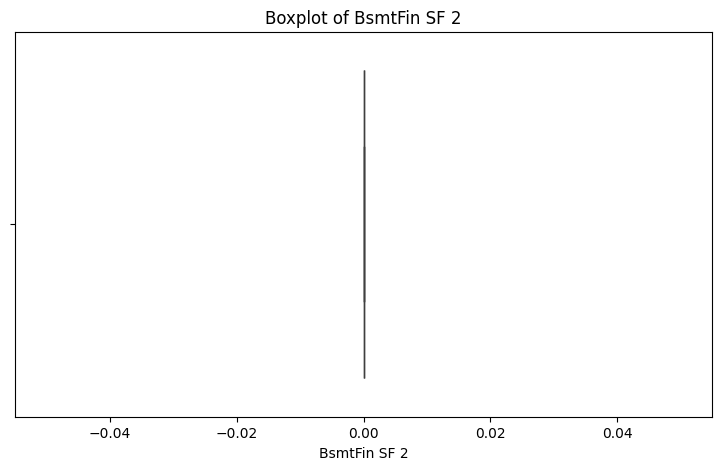

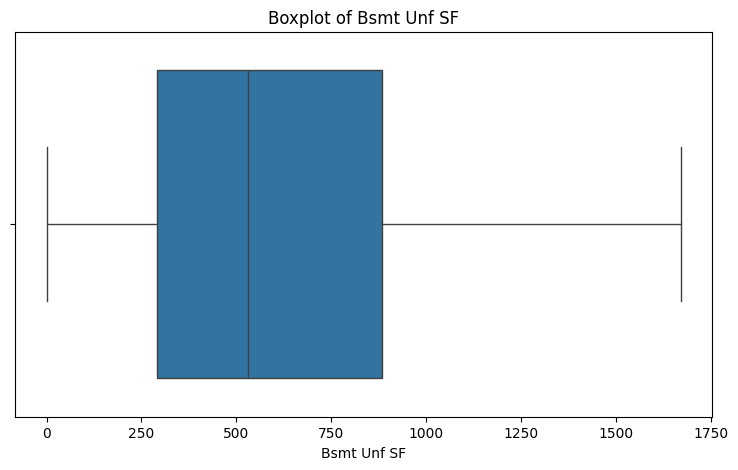

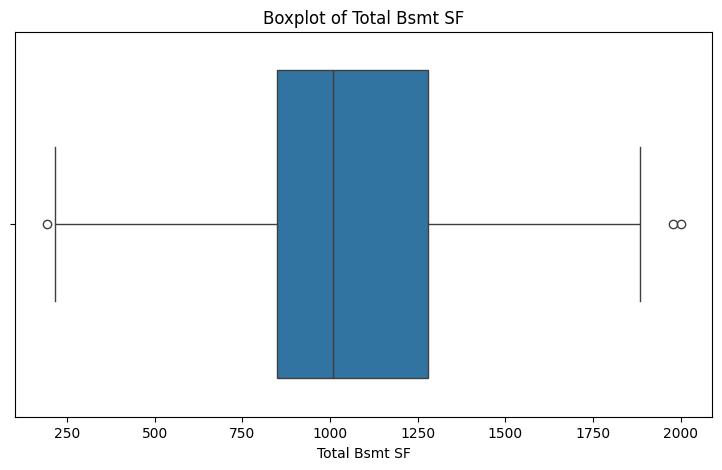

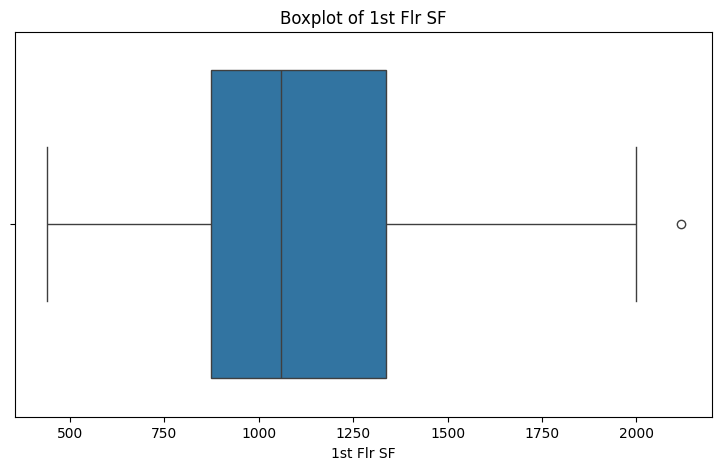

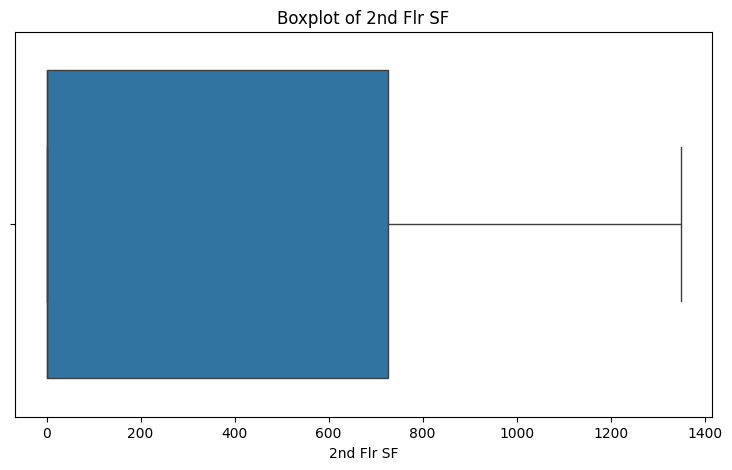

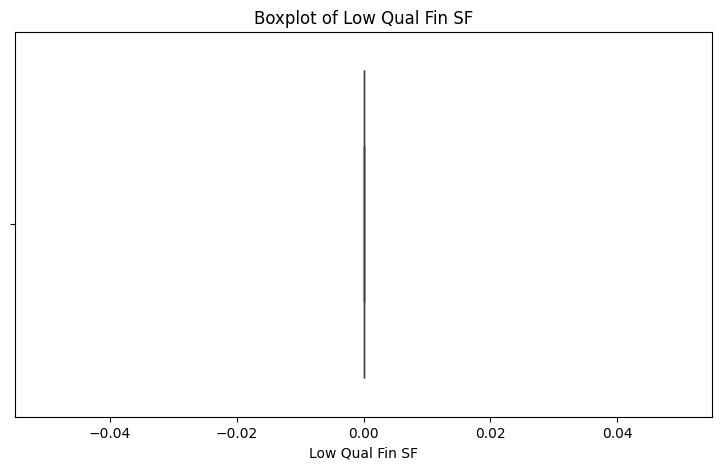

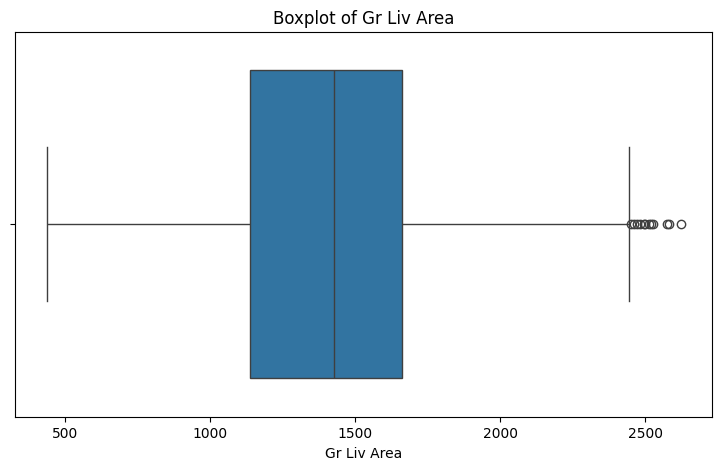

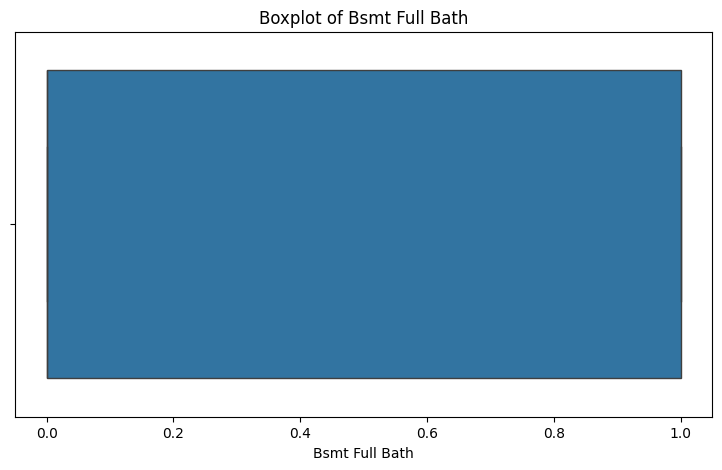

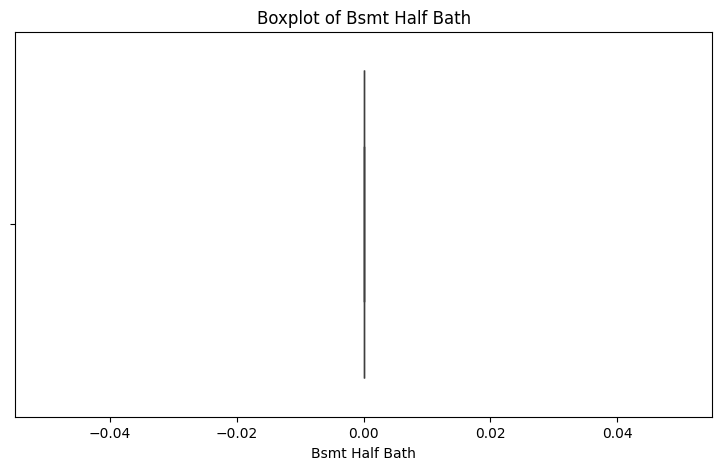

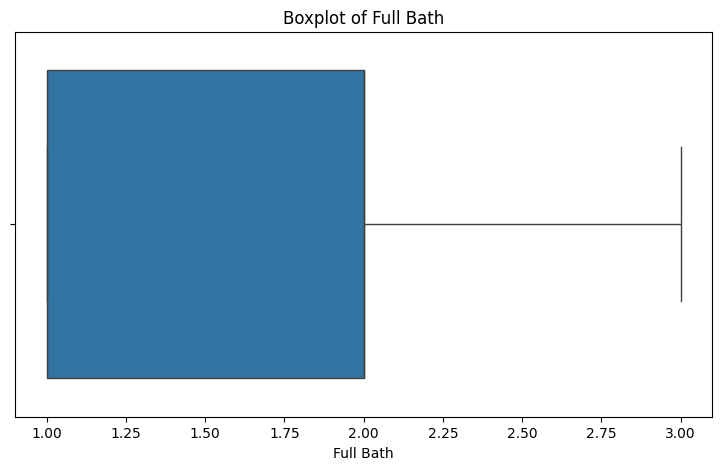

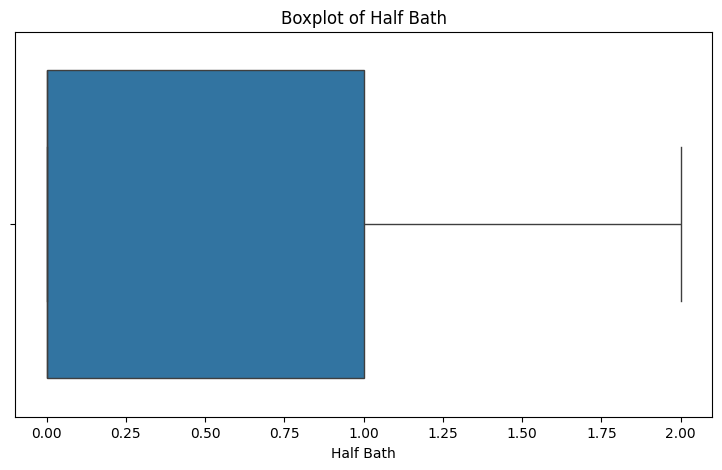

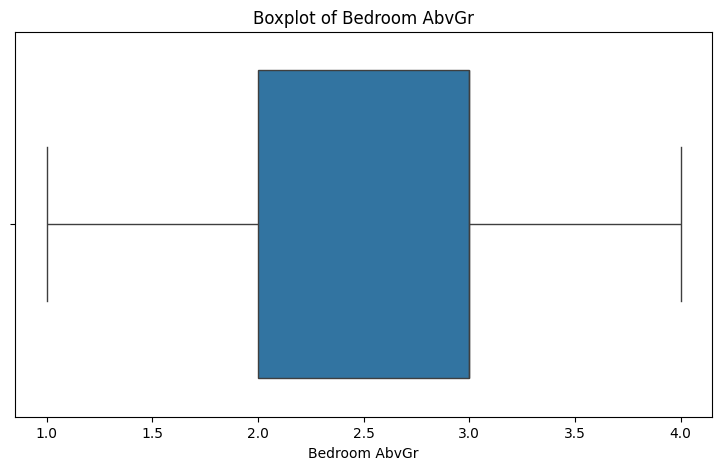

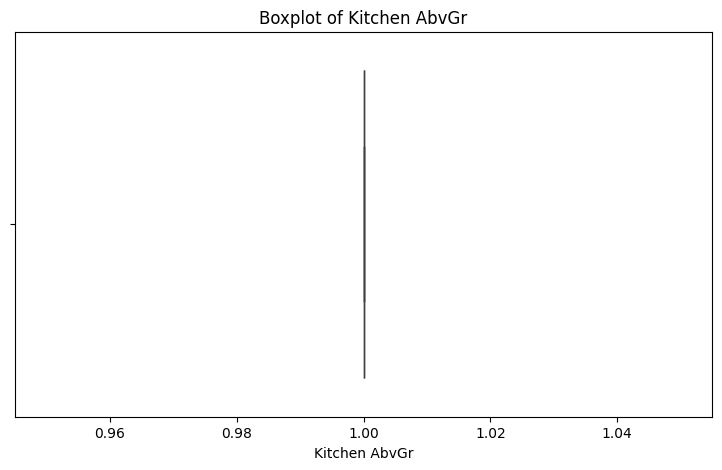

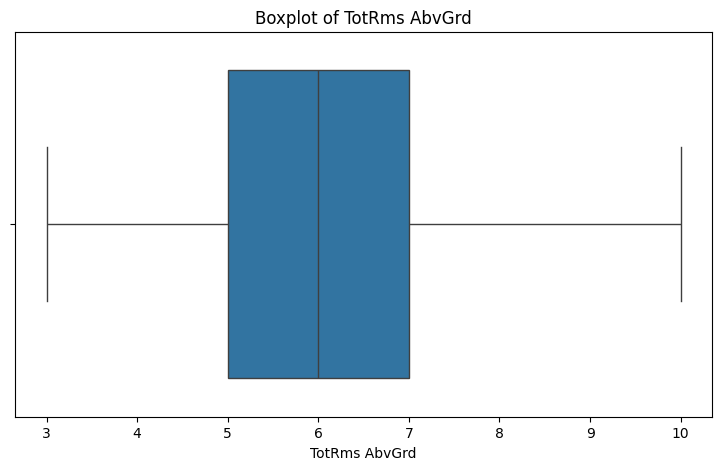

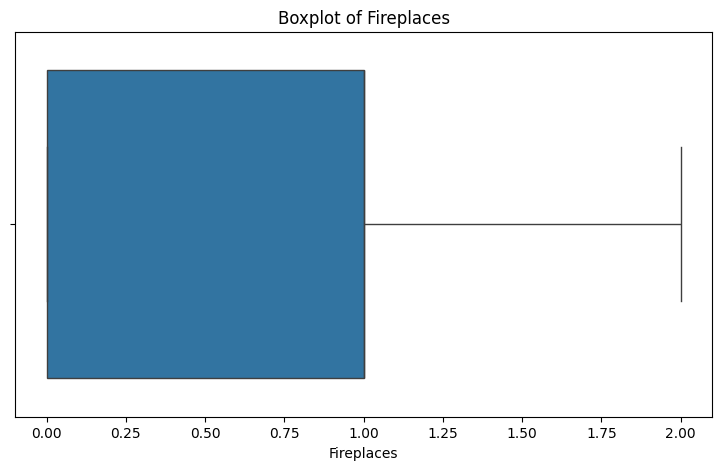

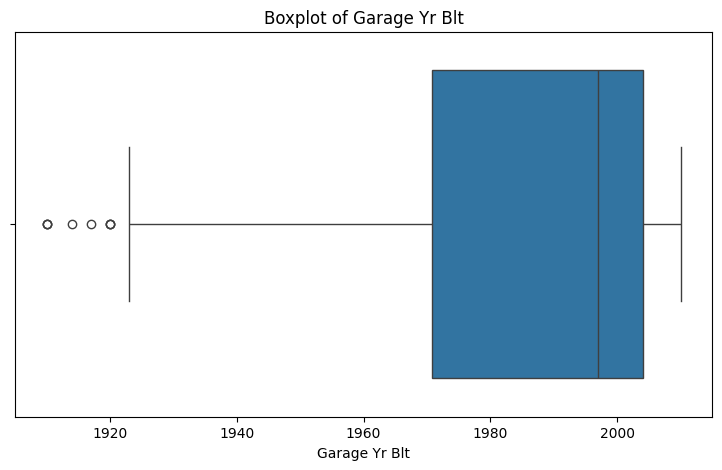

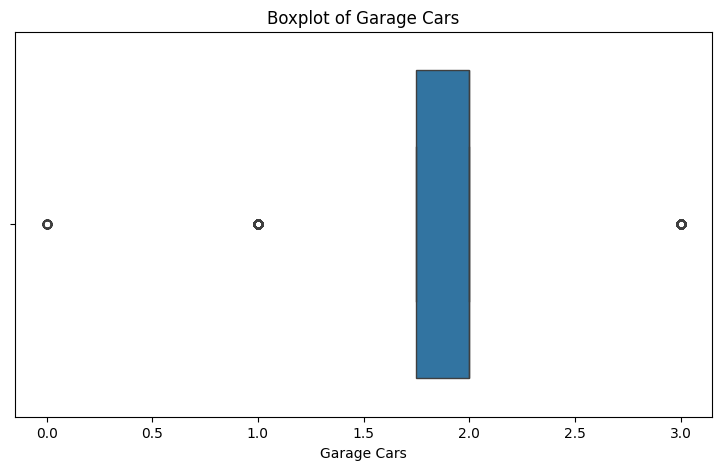

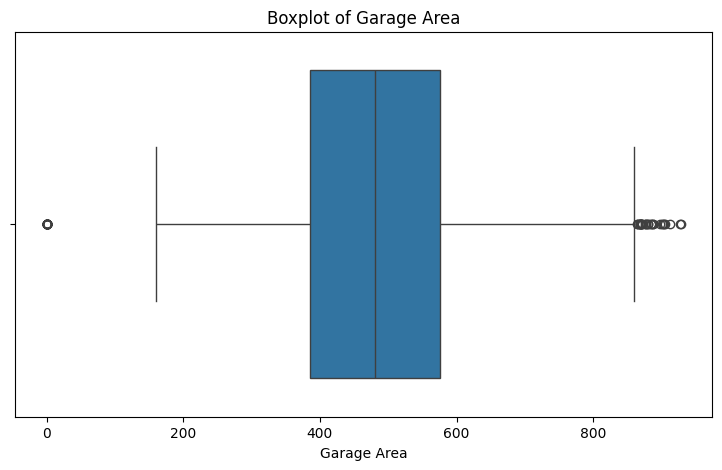

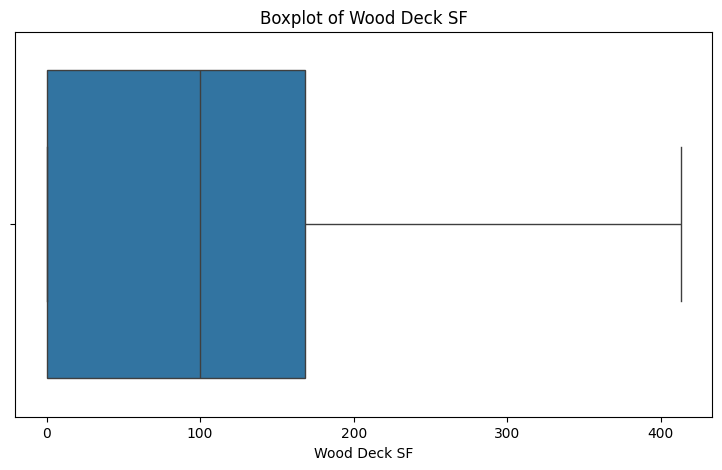

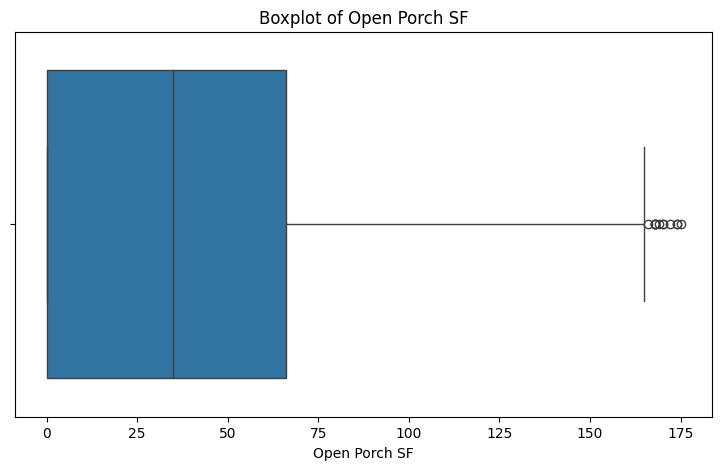

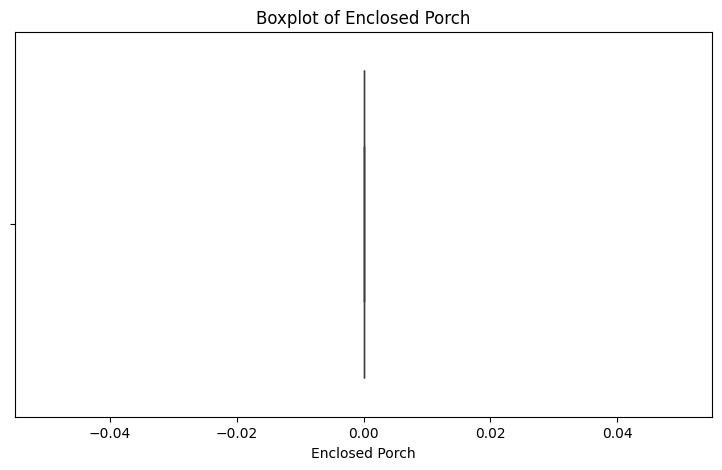

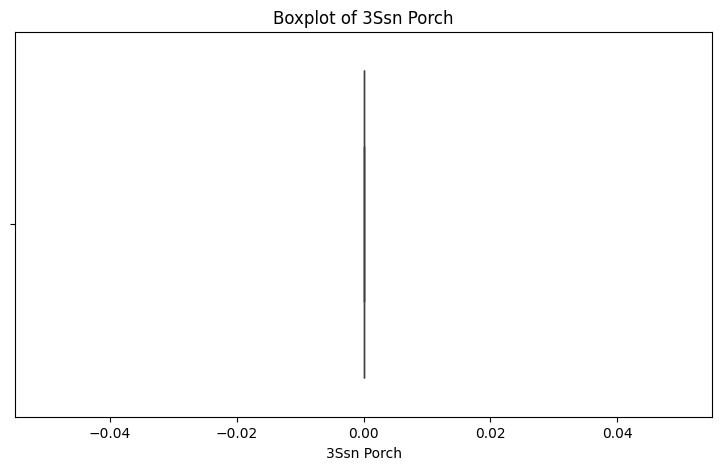

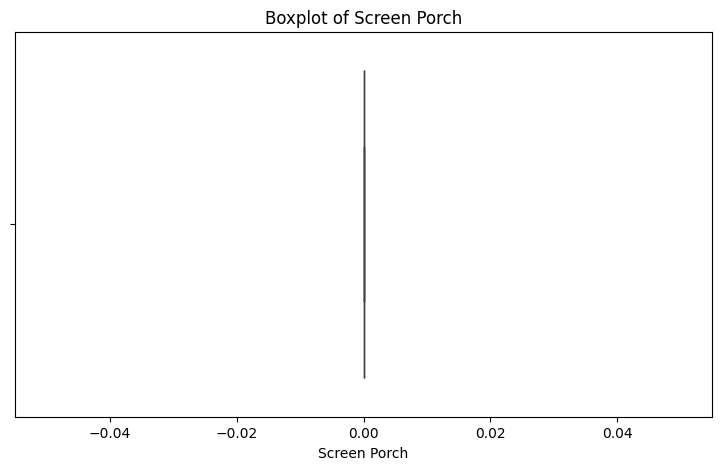

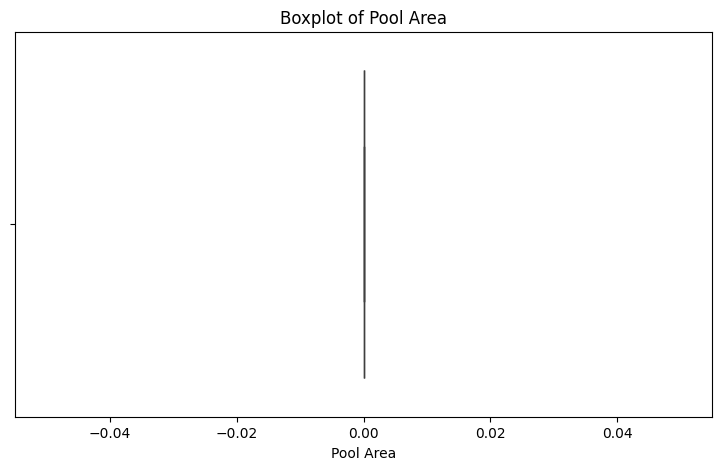

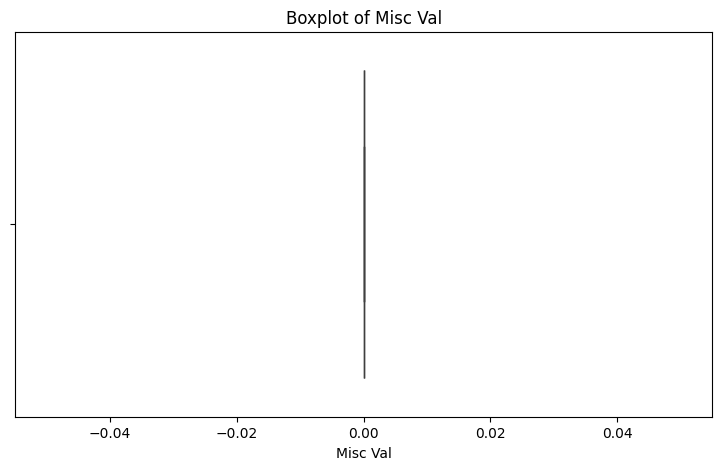

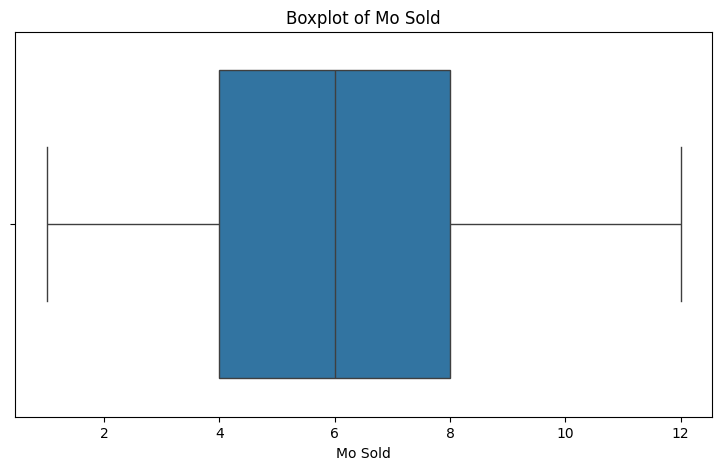

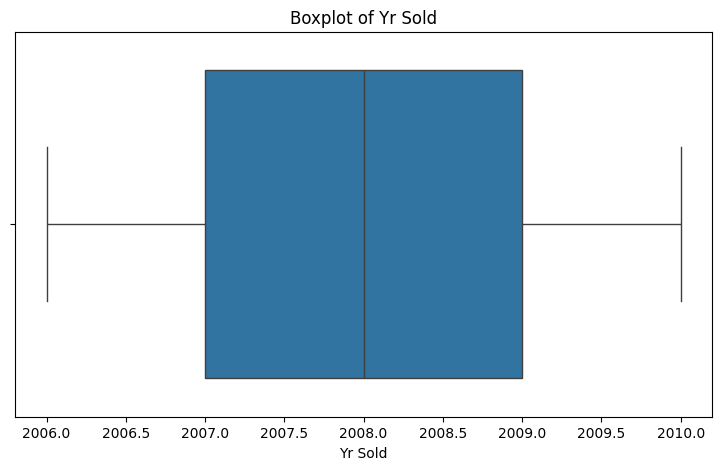

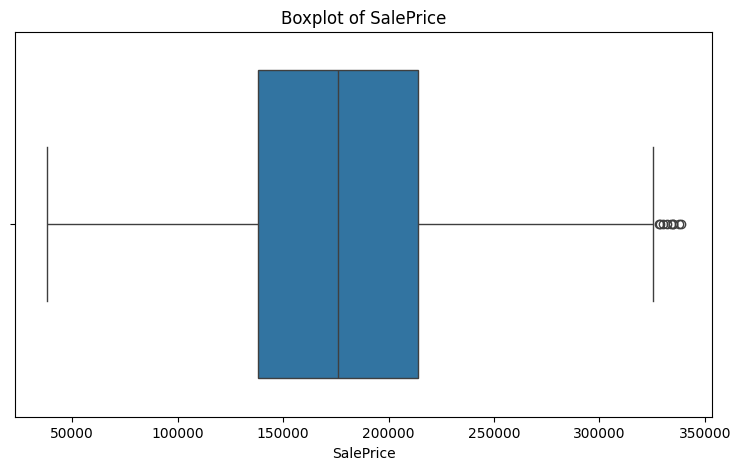

In [13]:
for feature in numeric_features:
    plt.figure(figsize=(9, 5))
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

### 2.4 Normalisasi dan Standarisasi Data

Keputusan: Kita akan melakukan standarisasi data.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

Text(0.5, 1.0, 'Histogram Sebelum Standardisasi')

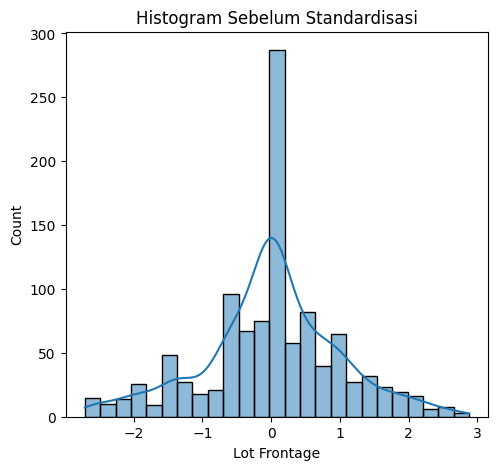

In [16]:
# Histogram Sebelum Standardisasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[numeric_features[3]], kde=True)
plt.title("Histogram Sebelum Standardisasi")

Text(0.5, 1.0, 'Histogram Setelah Standardisasi')

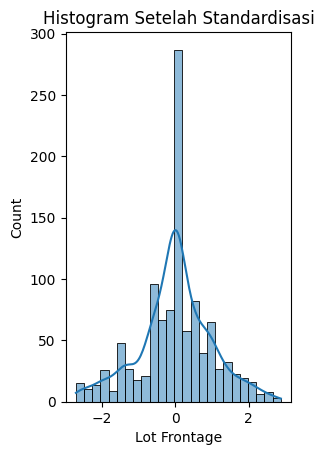

In [17]:
# Histogram Setelah Standardisasi
plt.subplot(1, 2, 2)
sns.histplot(df[numeric_features[3]], kde=True)
plt.title("Histogram Setelah Standardisasi")

### 2.5 Duplikasi Data

Keputusan: Menghapus data duplikat.

In [19]:
duplicates = df.duplicated().sum()

print(f"Jumlah baris duplikat: {duplicates}")

Jumlah baris duplikat: 0


Keterangan: TidaK dideteksi duplikasi data.

### 2.6 Mengonversi Tipe Data

Keterangan: Perhatikan lagi data kategorikal.

In [23]:
categorical_features = df.select_dtypes(include=['object', 'str']).columns
df[categorical_features].head()

,MS Zoning,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,...,Kitchen Qual,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition
4,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,...,TA,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal
5,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,...,Gd,Typ,Gd,Attchd,Fin,TA,TA,Y,WD,Normal
8,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,StoneBr,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
9,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,...,Gd,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal
10,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Gilbert,Norm,Norm,...,TA,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal


Keputusan: Kita akan menggunakan metode one hot encoding dan label encoding karena data kategorikal yang ada pada dataset ini tidak memiliki urutan.

#### 2.6.1 One Hot Encoding

In [22]:
df_one_hot = pd.get_dummies(df, columns=categorical_features)
df_one_hot.head()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Sale Type_ConLI,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_WD,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
4,-1.733960,-0.901060,0.340641,0.473342,1.694238,-1.003022,-0.53115,0.531056,0.437228,-0.693366,...,False,False,False,False,True,False,False,False,True,False
5,-1.732765,-0.901060,0.340641,0.784066,0.274332,-0.215036,0.89746,0.570522,0.437228,-0.498554,...,False,False,False,False,True,False,False,False,True,False
8,-1.729182,-0.900842,2.257241,-2.245492,-1.417244,1.360935,-0.53115,0.452124,0.335847,-0.693366,...,False,False,False,False,True,False,False,False,True,False
9,-1.727987,-0.900756,0.340641,-0.614192,-0.639097,0.572949,-0.53115,0.609988,0.487919,-0.693366,...,False,False,False,False,True,False,False,False,True,False
10,-1.726793,-0.900751,0.340641,0.551023,0.282441,-0.215036,-0.53115,0.373192,0.234467,-0.693366,...,False,False,False,False,True,False,False,False,True,False


#### 2.6.2 Label Encoding

In [24]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df_lencoder = pd.DataFrame(df)


for column in categorical_features:
    df_lencoder[column] = label_encoder.fit_transform(df[column])

df_lencoder.head()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Kitchen Qual,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition
4,-1.733960,-0.901060,0.340641,0.473342,1.694238,-1.003022,-0.53115,0.531056,0.437228,-0.693366,...,3,5,4,1,0,3,4,2,8,3
5,-1.732765,-0.901060,0.340641,0.784066,0.274332,-0.215036,0.89746,0.570522,0.437228,-0.498554,...,2,5,2,1,0,3,4,2,8,3
8,-1.729182,-0.900842,2.257241,-2.245492,-1.417244,1.360935,-0.53115,0.452124,0.335847,-0.693366,...,2,5,4,1,1,3,4,2,8,3
9,-1.727987,-0.900756,0.340641,-0.614192,-0.639097,0.572949,-0.53115,0.609988,0.487919,-0.693366,...,2,5,4,1,0,3,4,2,8,3
10,-1.726793,-0.900751,0.340641,0.551023,0.282441,-0.215036,-0.53115,0.373192,0.234467,-0.693366,...,3,5,4,1,0,3,4,2,8,3
